'best_m.keras'에서 모델을 로드합니다...
모델 로드 완료.
테스트용 샘플 이미지를 로드합니다...
샘플 로드 완료.
예측을 수행합니다...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
예측 완료.

--- 최종 예측 결과 ---
실제 정답 (숫자): Ankle boot
모델 예측 (숫자): Ankle boot


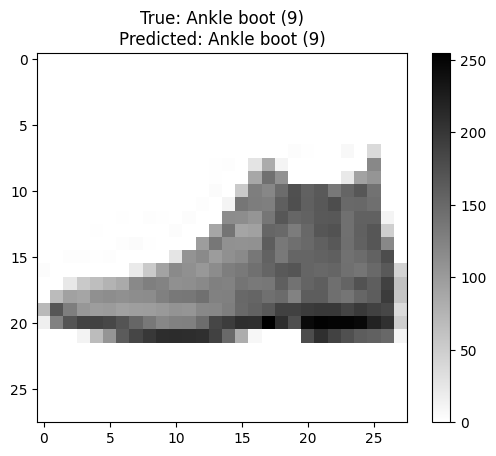

In [1]:
# 1. 데이터 전처리
# 2. 모델 선정 검증
# 3. 후처리 내용
# 4. 예측기 함수는 1개로 통합

# import
import numpy as np
import cv2
from keras.models import load_model
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import os
import ssl

# 이미지 리사이징
def resize_image(image, target_size=(28, 28)):
    return cv2.resize(image, target_size)

def preprocess_image(image):
    resized = resize_image(image)
    normalized = resized / 255.0
    return np.expand_dims(np.expand_dims(normalized, axis=0), axis=-1)

def predict_number(image_array, model):
    preprocessed_image = preprocess_image(image_array)
    prediction_probs = model.predict(preprocessed_image)
    predicted_index = np.argmax(prediction_probs[0])
    return predicted_index

def main():
    """메인 실행 함수"""
    model_path = 'best_m.keras'
    if not os.path.exists(model_path):
        print(f"오류: 모델 파일 '{model_path}'을 찾을 수 없습니다.")
        print("노트북의 모델 학습 및 저장 셀을 먼저 실행했는지 확인하세요.")
        return

    # 1. 학습된 모델 로드
    print(f"'{model_path}'에서 모델을 로드합니다...")
    fashion_model = load_model(model_path)
    print("모델 로드 완료.")

    # 2. 테스트용 샘플 이미지 로드
    print("테스트용 샘플 이미지를 로드합니다...")
    (_, _), (test_images, test_labels) = fashion_mnist.load_data()
    sample_image = test_images[0]
    true_label_number = test_labels[0]
    print("샘플 로드 완료.")

    # 3. 예측 실행
    print("예측을 수행합니다...")
    predicted_number = predict_number(sample_image, fashion_model)
    print("예측 완료.")

    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # 4. 결과 출력
    print("\n--- 최종 예측 결과 ---")
    print(f"실제 정답 : {class_names[true_label_number]}")
    print(f"모델 예측 : {class_names[predicted_number]}")

    # 5. 이미지 시각화
    plt.figure()
    plt.imshow(sample_image, cmap=plt.cm.binary)
    plt.title(f"True: {class_names[true_label_number]} ({true_label_number})\nPredicted: {class_names[predicted_number]} ({predicted_number})")
    plt.show()

if __name__ == '__main__':
    main()